#### Import Libraries

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import  accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits

#### load Dataset

In [82]:
digits = load_digits()

X = digits.data       
y = digits.target  
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Finding Best K

In [83]:
k_values = [1, 3, 5, 7, 9]
best = []


for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    confuse = confusion_matrix(y_test, y_pred)
    best.append((k, acc))
    

In [84]:
best_model = sorted(best,key=lambda x:x[1],reverse=True)
best_model
perfect_K = best_model[0][0]
best_acc = best_model[0][1]
best_acc = round(best_acc*100,2)
print(f"Best K for this dataset are :\n{perfect_K} with accuracy of {best_acc}%")

Best K for this dataset are :
7 with accuracy of 98.89%


#### Fitting model

In [85]:
model = KNeighborsClassifier(n_neighbors=perfect_K)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#### Confusion matric

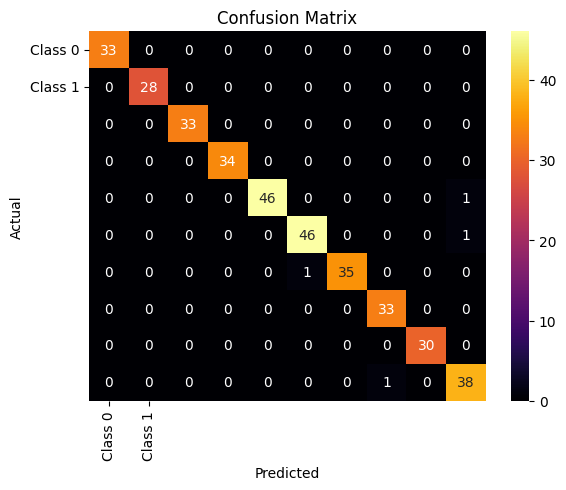

In [ ]:
confuse = confusion_matrix(y_pred,y_test)
labels = ['Class 0', 'Class 1']
  
sns.heatmap(confuse, annot=True, fmt='d', cmap='inferno', xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
classify = classification_report(y_test,y_pred)
print(classify)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

